
Ingeniería de características (FE)

---

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
import os
#DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC4029 - Ciencia y analítica de datos/Semana 6/Actividad6_FE"
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC4029 - Ciencia y analítica de datos/Semana 6/Actividad6_FE"
os.chdir(DIR)


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [71]:
cars_df = pd.read_csv('vehicles.csv')
cars_df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [72]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

# **Parte 1**. Preprocesamiento

1a)    Elimina las columnas que no serán relevantes para esta actividad: `id`, `VIN`, `url`, `image_url`, `description`, `posting_date`, `lat`, `long`.


In [73]:
#Guardar en variables el valor original de filas y columnas del dataset
cars_df_original_filas = cars_df.shape[0]
cars_df_original_columnas= cars_df.shape[1]
print(f"El dataframe original tiene {cars_df_original_filas} filas y {cars_df_original_columnas} columnas")


El dataframe original tiene 426880 filas y 26 columnas


In [74]:
#Elimina las columnas ['id', 'VIN', 'url', 'image_url', 'description', 'posting_date', 'lat', 'long']
cars_df=cars_df.drop(columns=['id', 'VIN', 'url', 'image_url', 'description', 'posting_date', 'lat', 'long'], errors='ignore')
print("Updated dataframe \n")
print(cars_df.info())
cars_df

Updated dataframe 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   region_url    426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  drive         296313 non-null  object 
 13  size          120519 non-null  object 
 14  type          334022 non-null  object 
 15  paint_color   296677 non-null  object 
 16  county        0 non-null       float64
 17  state         426880 non-nul

,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,state
0,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,NaN,wy
426876,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,NaN,wy
426877,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,NaN,wy
426878,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,NaN,wy


1b) Almacena en una variable la cantidad de observaciones o registros del dataframe y en otra el número de columnas (después del borrado) para análisis posteriores.

In [75]:
#Guardar en variables el valor  filas y columnas después de remover 6 columnas
cars_df_paso1_filas = cars_df.shape[0]
cars_df_paso1_columnas= cars_df.shape[1]
print(f"El dataframe en paso1 tiene {cars_df_paso1_filas} filas y {cars_df_paso1_columnas} columnas")

El dataframe en paso1 tiene 426880 filas y 18 columnas


## Valores faltantes

Cuando la cantidad de valores faltantes en una columna es lo suficientemente grande (aproximadamente más del 25%), estimar e ingresar los valores faltantes no tiene sentido, y eliminar el atributo es mejor que estimar los valores faltantes. https://learning.oreilly.com/library/view/hands-on-data-preprocessing/9781801072137/B17397_11_Final_NM_ePub.xhtml#_idParaDest-188

Sin embargo, esto no es una regla aplicable a todos los escenarios y hay muchas discusiones en torno a ello. https://www.quora.com/How-much-missing-data-is-too-much-1

Para esta actividad  utilizaremos un umbral de 0.70 de la cantidad de registros (aquellas columnas que tengan 70% de valores no nulos). Considera además que estamos asumiendo que dichas variables son MCAR o MAR sin ninguna método gráfico o estadístico.

2a) Determina el porcentaje de valores faltantes por columna y elimina aquellas que posean el 30% o más de valores perdidos. Para ello utiliza el parámetro `thresh` de la función `dropna()` ¿Cuántas columnas se eliminaron?




---


***Primeramente se necesita obtener el porcentaje de valores faltantes para cada columna posterior a la eliminación del paso anterior. Al obtener los resultados podemos observar que las columnas condition, cylinders, drive, size, paint_color y county tienen un porcentaje mayor al 30%.***


---



In [76]:
#Obtiene el procentaje de valores faltantes por columna
round(cars_df.isna().mean().to_frame().T*100, 2)

,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,state
0,0.0,0.0,0.0,0.28,4.13,1.24,40.79,41.62,0.71,1.03,1.93,0.6,30.59,71.77,21.75,30.5,100.0,0.0




---


***Se utiliza dropna con los parámetros axis=1 el cual elimina columnas, thresh = 0.7 multiplicado por la cantidad de registros que se tienen para eliminar solamente las columnas con 30% de valores faltantes, tambien se agrega inplace=True para aplicar los resultados en el dataframe.***


---



In [77]:
#Elimina las columnas con más de 30% de valores faltantes
cars_df.dropna(axis=1,thresh=0.7*len(cars_df), inplace=True)
cars_df

,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
0,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,gas,32226.0,clean,other,sedan,wy
426876,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,gas,12029.0,clean,other,sedan,wy
426877,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,diesel,4174.0,clean,other,hatchback,wy
426878,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,gas,30112.0,clean,other,sedan,wy


Además, cuando tenemos grandes conjuntos de datos, podemos eliminar filas que contienen valores nulos. Aunque, no se recomienda eliminar filas si el porcentaje de valores faltantes en el conjunto de datos es superior al 30%
https://medium.com/analytics-vidhya/how-to-deal-with-missing-values-in-data-set-8e8f70ecf155



---


***Para este punto se eliminaron en total 6 columnas, quedando solamente 12 en el nuevo dataframe***


---



2b) Borra los registros que contengan `NaN` en las columnas con menos del 5% de valores faltantes empleando el parámetro subset ¿Qué porcentaje de los registros iniciales se eliminaron?




---


***Se puede observar en la siguiente lista que las columnas year, manufacturer, model, fuel, odometer, title_status, transmission tienen un porcentaje menor al 5% de valores faltantes, el caso de type es diferente ya que tiene un 21.75% de valores faltantes.***


---



In [78]:
#Obtiene el porcentaje de valores faltantes por columna
round(cars_df.isna().mean().to_frame().T*100, 2)

,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
0,0.0,0.0,0.0,0.28,4.13,1.24,0.71,1.03,1.93,0.6,21.75,0.0


In [79]:
#Borra los registros NaN de las columnas
cars_df.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'], inplace=True)
cars_df

,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
27,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,gas,57923.0,clean,other,pickup,al
28,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,gas,71229.0,clean,other,pickup,al
29,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,gas,19160.0,clean,other,pickup,al
30,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,gas,41124.0,clean,other,pickup,al
31,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,gas,128000.0,clean,automatic,truck,al
...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,gas,32226.0,clean,other,sedan,wy
426876,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,gas,12029.0,clean,other,sedan,wy
426877,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,diesel,4174.0,clean,other,hatchback,wy
426878,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,gas,30112.0,clean,other,sedan,wy




---


***Posterior a la eliminación realizamos una verficación, y podemos ver que la longitud disminuyó al igual que ya no existen porcentajes faltantes fuera de type***


---



In [80]:
#Despliega el porcentaje de valores faltantes después de la eliminación
print("Longitud después de la eliminacion:",cars_df.shape[0])
round(cars_df.isna().mean().to_frame().T*100, 2)

Longitud después de la eliminacion: 389604


,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.21,0.0




---
***Se eliminaron 37276 registros que corresponden a 8.7% del total***

---




2c) Si hay variables que aún poseen valores faltantes, utiliza el método de imputación apropiado (`mean, median, mode`)



---

***Se observa en el siguiente código que type es una variable categórica por lo que la media y la mediana no van a funcionar para realizar la imputación de valores, se utilizará la moda***


---



In [81]:
#Obtiene los valores únicos de type
cars_df['type'].unique()

array(['pickup', 'truck', 'other', nan, 'coupe', 'SUV', 'hatchback',
       'mini-van', 'sedan', 'offroad', 'van', 'convertible', 'wagon',
       'bus'], dtype=object)

In [82]:
#Calcula las frecuencias de los valores únicos
cars_df['type'].value_counts()

,count
type,
sedan,80976
SUV,71578
pickup,40934
truck,32035
other,19442
coupe,17109
hatchback,14998
wagon,10095
van,7518




---


***Aquí se observa que la moda de la columna type es sedan al igual que en el value_counts anterior ya que están ordenados los valores.***


---



In [83]:
#Caracteristicas de la columna type
cars_df['type'].describe().to_frame().T

,count,unique,top,freq
type,306976,13,sedan,80976




---


***Ahora la cantidad de autos tipo sedan a aumentado de 80,976 a 163,604 registros***


---



In [84]:
#Frecuencia de los valores únicos para type
cars_df.fillna(cars_df['type'].mode()[0], inplace=True)
cars_df['type'].value_counts()

,count
type,
sedan,163604
SUV,71578
pickup,40934
truck,32035
other,19442
coupe,17109
hatchback,14998
wagon,10095
van,7518




---


***Se confirma que ahora ninguna columna cuenta con valores faltantes***


---



In [85]:
#Despliega el porcentaje de valores faltantes
round(cars_df.isna().mean().to_frame().T*100, 2)

,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Valores atípicos

3a) Obtén el histograma de las variables `price`, `year` y `odometer` para observar su distribución.

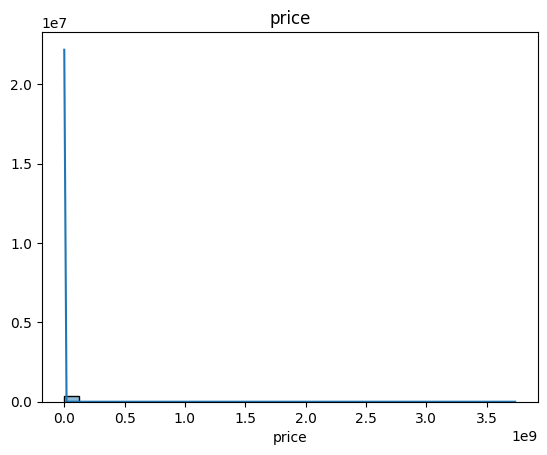

In [86]:
sns.histplot(cars_df['price'], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("price")
plt.ylabel("")
plt.title("price")

# Mostrar el gráfico
plt.show()

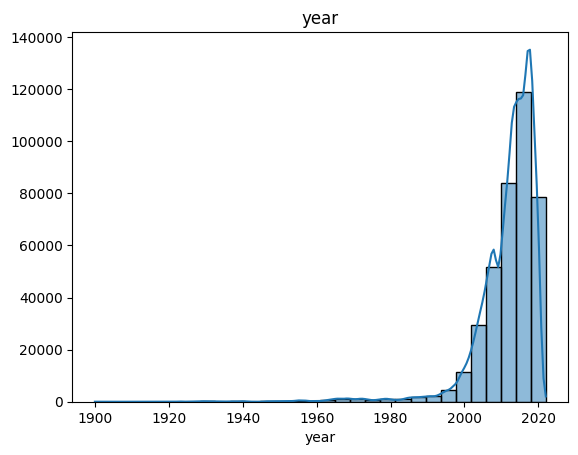

In [87]:
sns.histplot(cars_df["year"], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("year")
plt.ylabel("")
plt.title("year")

# Mostrar el gráfico
plt.show()

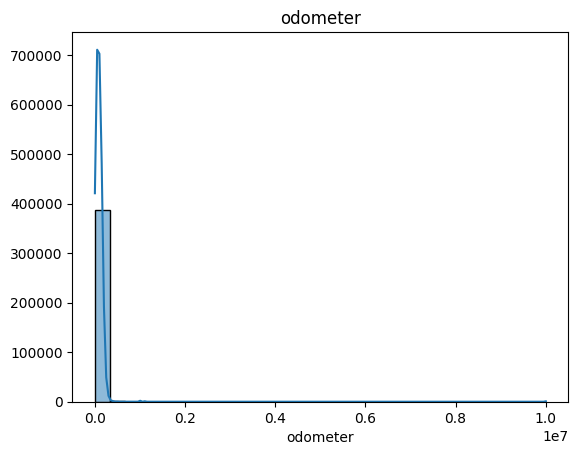

In [88]:
sns.histplot(cars_df["odometer"], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("odometer")
plt.ylabel("")
plt.title("odometer")

# Mostrar el gráfico
plt.show()

3b) Añade la columna `age`, calculada a partir de `year`, para determinar los años del vehículo y una vez obtenida, elimina la columna `year`. Genera el histograma de la nueva variable.

In [89]:
# Año máximo en la lista
year_max = cars_df['year'].max()

# Crear la nueva columna 'age'
cars_df['age'] = year_max - cars_df['year']
cars_df['age']

,age
27,8.0
28,12.0
29,2.0
30,5.0
31,9.0
...,...
426875,3.0
426876,2.0
426877,2.0
426878,4.0


In [90]:
# Eliminar la columna 'year'
cars_df.drop(columns=['year'], inplace=True)

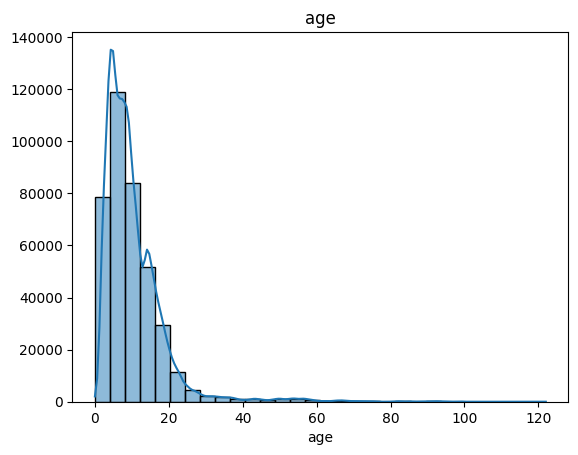

In [91]:
sns.histplot(cars_df["age"], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("age")
plt.ylabel("")
plt.title("age")

# Mostrar el gráfico
plt.show()

4a) Para visualizar si hay valores atípicos, genera gráficos de box plot para las tres variables (`price, age, odometer`)

<Axes: title={'center': 'Price'}>

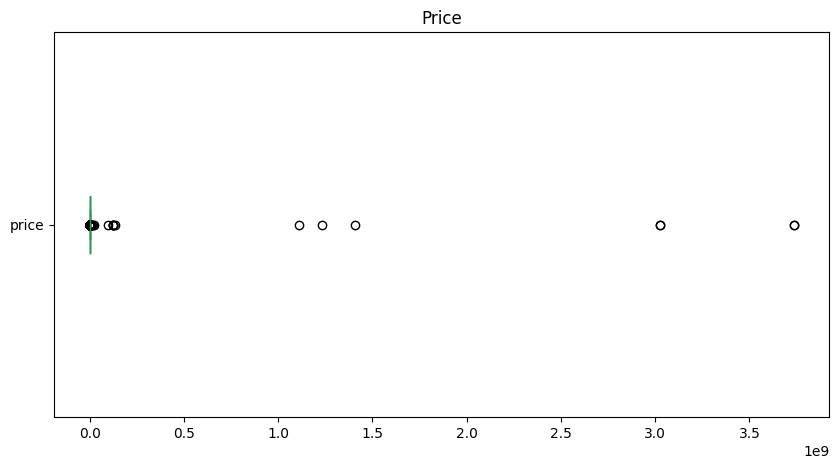

In [92]:
#Se grafica la variable de price con un boxplot para confirmar si hay valores atípicos
cars_df['price'].plot(kind="box", title="Price", figsize=(10,5), vert = False)

In [93]:
#Se obtienen los valores atípicos haciendo uso de los cuartiles
Q1 = cars_df.price.quantile(0.25)
Q3 = cars_df.price.quantile(0.75)
IQR = Q3-Q1

BM = (cars_df.price > (Q3+1.5 *IQR)) | (cars_df.price < (Q1-1.5 *IQR))
outliers_price_df = cars_df[BM]
outliers_price_df

,region,region_url,price,manufacturer,model,fuel,odometer,title_status,transmission,type,state,age
204,birmingham,https://bham.craigslist.org,58977,gmc,sierra 3500,gas,66368.0,clean,automatic,sedan,al,3.0
346,birmingham,https://bham.craigslist.org,98900,ferrari,360 modena,gas,20187.0,clean,automatic,convertible,al,21.0
365,birmingham,https://bham.craigslist.org,72900,chevrolet,tahoe,gas,19129.0,clean,automatic,SUV,al,1.0
461,birmingham,https://bham.craigslist.org,99950,chevrolet,corvette stingray spor,gas,510.0,clean,automatic,coupe,al,1.0
732,birmingham,https://bham.craigslist.org,100000,jeep,cj7,gas,112000.0,clean,manual,sedan,al,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...
426651,wyoming,https://wyoming.craigslist.org,74900,ford,f250 crew cab diesel,diesel,30290.0,clean,automatic,sedan,wy,3.0
426694,wyoming,https://wyoming.craigslist.org,59900,ford,f550 xl,diesel,156000.0,clean,automatic,sedan,wy,8.0
426716,wyoming,https://wyoming.craigslist.org,65950,ford,f450,diesel,21300.0,clean,automatic,truck,wy,2.0
426778,wyoming,https://wyoming.craigslist.org,65995,gmc,sierra,gas,11349.0,clean,automatic,truck,wy,2.0


<Axes: title={'center': 'Age'}>

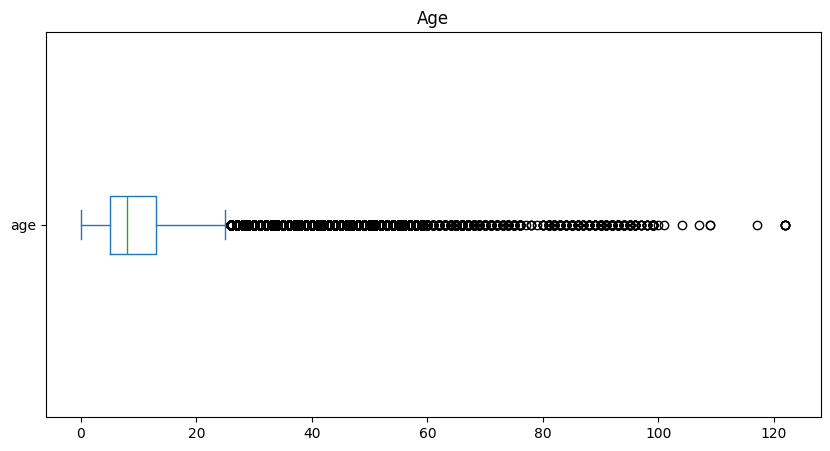

In [94]:
#Se grafica la variable de age con un boxplot para confirmar si hay valores atípicos
cars_df['age'].plot(kind="box", title="Age", figsize=(10,5), vert = False)

In [95]:
#Se obtienen los valores atípicos haciendo uso de los cuartiles
Q1 = cars_df.age.quantile(0.25)
Q3 = cars_df.age.quantile(0.75)
IQR = Q3-Q1

BM2 = (cars_df.age > (Q3+1.5 *IQR)) | (cars_df.age < (Q1-1.5 *IQR))
outliers_age_df = cars_df[BM2]
outliers_age_df

,region,region_url,price,manufacturer,model,fuel,odometer,title_status,transmission,type,state,age
37,auburn,https://auburn.craigslist.org,4500,jeep,cherokee,gas,192000.0,clean,automatic,sedan,al,30.0
208,birmingham,https://bham.craigslist.org,2500,chevrolet,malibu classic,gas,100.0,clean,automatic,sedan,al,46.0
210,birmingham,https://bham.craigslist.org,1300,mercedes-benz,benz,gas,12774.0,clean,automatic,sedan,al,53.0
219,birmingham,https://bham.craigslist.org,2500,bmw,525i,gas,110661.0,clean,automatic,sedan,al,27.0
228,birmingham,https://bham.craigslist.org,5500,ford,f-150,gas,239000.0,clean,automatic,truck,al,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...
426686,wyoming,https://wyoming.craigslist.org,28900,chevrolet,1500 silverado,gas,28700.0,clean,automatic,sedan,wy,37.0
426729,wyoming,https://wyoming.craigslist.org,20000,jeep,cj 3a willys,gas,14409.0,clean,manual,other,wy,71.0
426762,wyoming,https://wyoming.craigslist.org,7000,mazda,rx& gls sport,gas,80000.0,clean,automatic,coupe,wy,40.0
426809,wyoming,https://wyoming.craigslist.org,18000,jeep,gand wagoneer,gas,114400.0,clean,automatic,SUV,wy,32.0


<Axes: title={'center': 'Odometer'}>

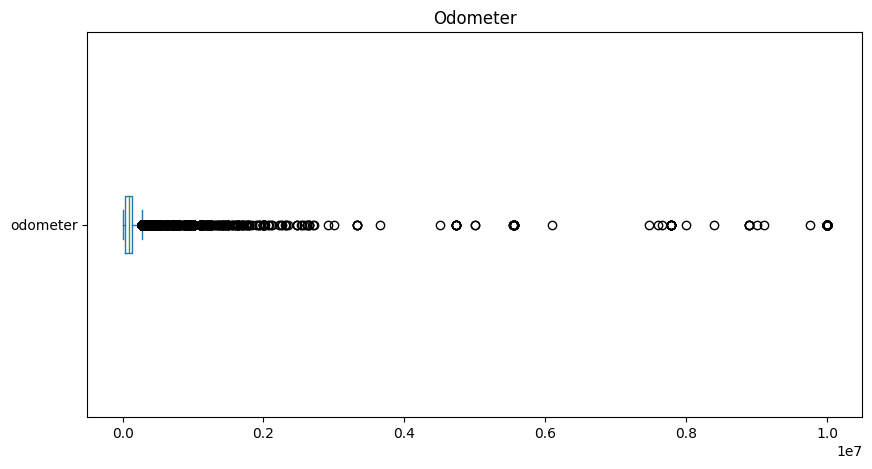

In [96]:
#Se grafica la variable de odometer con un boxplot para confirmar si hay valores atípicos
cars_df['odometer'].plot(kind="box", title="Odometer", figsize=(10,5), vert = False)

In [97]:
#Se obtienen los valores atípicos haciendo uso de los cuartiles
Q1 = cars_df.odometer.quantile(0.25)
Q3 = cars_df.odometer.quantile(0.75)
IQR = Q3-Q1

BM3 = (cars_df.odometer > (Q3+1.5 *IQR)) | (cars_df.odometer < (Q1-1.5 *IQR))
outliers_odometer_df = cars_df[BM3]
outliers_odometer_df

,region,region_url,price,manufacturer,model,fuel,odometer,title_status,transmission,type,state,age
138,auburn,https://auburn.craigslist.org,4000,jeep,grand cherokee laredo,gas,281000.0,clean,automatic,SUV,al,16.0
411,birmingham,https://bham.craigslist.org,4500,acura,mdx,gas,279000.0,clean,automatic,SUV,al,17.0
484,birmingham,https://bham.craigslist.org,11500,ford,f-250 super duty xl,diesel,283356.0,clean,automatic,pickup,al,14.0
527,birmingham,https://bham.craigslist.org,5500,ford,e350 van,diesel,340000.0,clean,automatic,van,al,21.0
562,birmingham,https://bham.craigslist.org,27990,ram,2500 4x4,diesel,2222222.0,clean,automatic,truck,al,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
426507,wyoming,https://wyoming.craigslist.org,9500,ford,expedition el,gas,303000.0,clean,automatic,sedan,wy,6.0
426508,wyoming,https://wyoming.craigslist.org,4995,ford,e450,gas,284000.0,clean,automatic,sedan,wy,20.0
426643,wyoming,https://wyoming.craigslist.org,4200,toyota,sequoia,gas,287000.0,clean,automatic,SUV,wy,21.0
426671,wyoming,https://wyoming.craigslist.org,9900,chevrolet,2500 ls,diesel,291137.0,clean,automatic,sedan,wy,17.0


Si el conjunto de outliers es “relativamente grande” (aunque sabemos que deben andar alrededor de un 5% del conjunto total de datos), realizar una investigación particular sobre ellos que permita tomar mejores decisiones.

4b) Calcula, para cada variable, el porcentaje de sus valores atípicos y elimínalos del dataframe ¿Qué porcentaje de los registros iniciales se han eliminado en total hasta ahora?

In [98]:
#Calculo de porcentaje de valores atípicos
print("Total de valores atipicos para la variable price: ", len(outliers_price_df))
print("Porcentaje de valores atipicos: ", len(outliers_price_df)/len(cars_df)*100,"%")
print("Total de valores atipicos para la variable age: ", len(outliers_age_df))
print("Porcentaje de valores atipicos: ", len(outliers_age_df)/len(cars_df)*100,"%")
print("Total de valores atipicos para la variable odometer: ", len(outliers_odometer_df))
print("Porcentaje de valores atipicos: ", len(outliers_odometer_df)/len(cars_df)*100,"%")

Total de valores atipicos para la variable price:  6656
Porcentaje de valores atipicos:  1.7084013511154916 %
Total de valores atipicos para la variable age:  14209
Porcentaje de valores atipicos:  3.647036478064907 %
Total de valores atipicos para la variable odometer:  3226
Porcentaje de valores atipicos:  0.8280202461987043 %


<Axes: title={'center': 'Price'}>

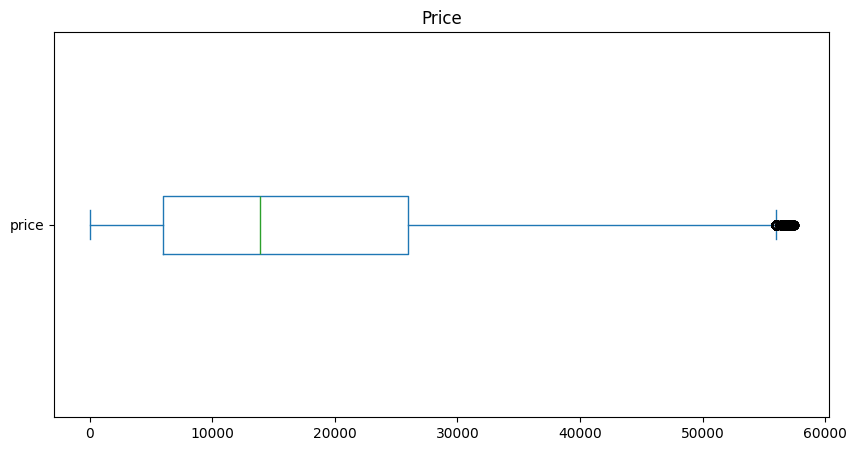

In [99]:
#Por ultimo hay que eliminar los valores atípicos del dataframe y evaluar con un boxplot si se logro
#Primero se realiza para la variable price
cars_df.drop(cars_df[BM].index, inplace=True)
cars_df['price'].plot(kind="box", title="Price", figsize=(10,5), vert = False)

<ipython-input-100-15135bdb18f0>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cars_df.drop(cars_df[BM2].index, inplace=True)


<Axes: title={'center': 'Age'}>

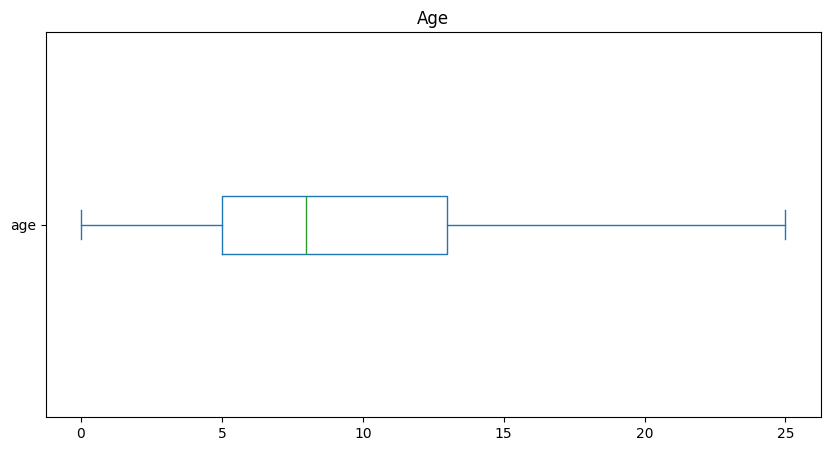

In [100]:
#Luego se realiza para la variable age
cars_df.drop(cars_df[BM2].index, inplace=True)
cars_df['age'].plot(kind="box", title="Age", figsize=(10,5), vert = False)

<ipython-input-101-7cb277151467>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cars_df.drop(cars_df[BM3].index, inplace=True)


<Axes: title={'center': 'Odometer'}>

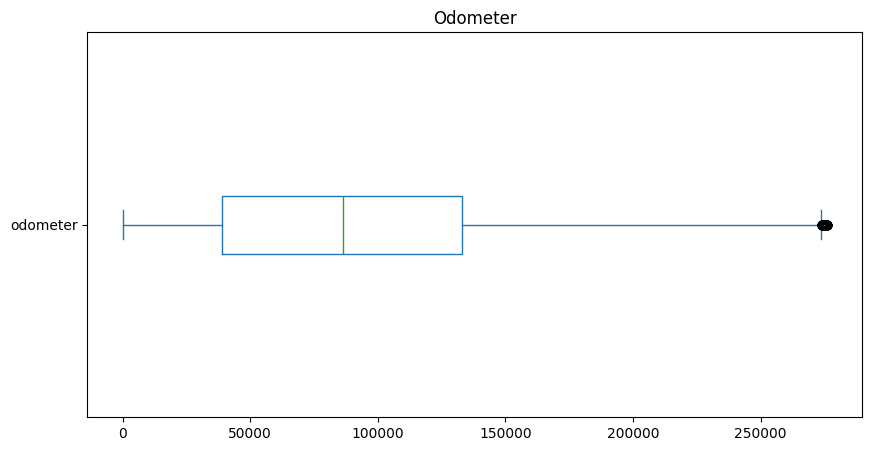

In [101]:
#Por último se realiza para la variable odometer
cars_df.drop(cars_df[BM3].index, inplace=True)
cars_df['odometer'].plot(kind="box", title="Odometer", figsize=(10,5), vert = False)

In [102]:
#Se calcula el porcentaje de registros que se han eliminado con respeto a los valores originales
print("Porcentaje de registros eliminados: ", (cars_df_original_filas-cars_df.shape[0])/cars_df_original_filas*100,"%")

Porcentaje de registros eliminados:  14.184782608695654 %


4c) Dibuja nuevamente los histogramas para observar claramente el sesgo de las variables tras la eliminación de los outliers.

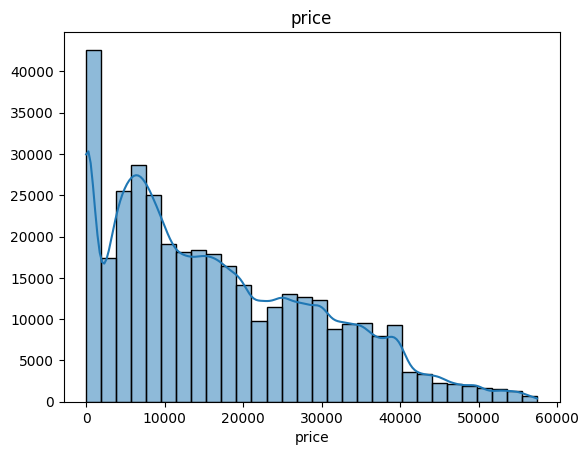

In [103]:
sns.histplot(cars_df['price'], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("price")
plt.ylabel("")
plt.title("price")

# Mostrar el gráfico
plt.show()

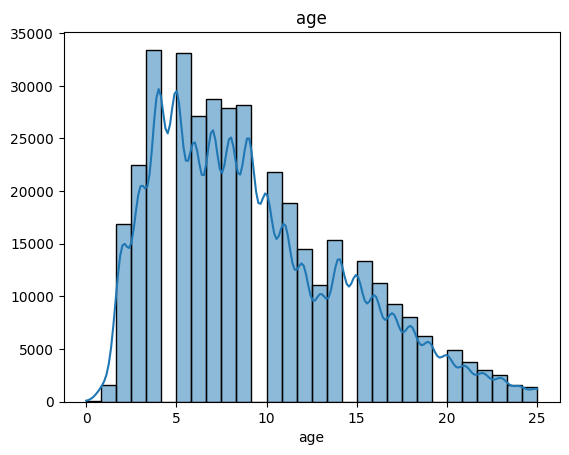

In [104]:
sns.histplot(cars_df["age"], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("age")
plt.ylabel("")
plt.title("age")

# Mostrar el gráfico
plt.show()

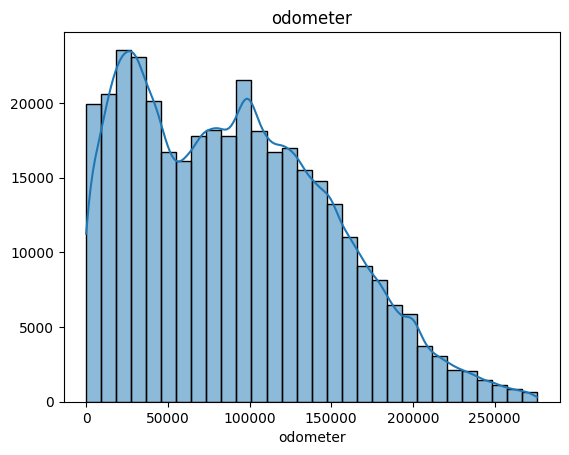

In [105]:
sns.histplot(cars_df["odometer"], kde=True, bins=30)

# Etiquetas y título
plt.xlabel("odometer")
plt.ylabel("")
plt.title("odometer")

# Mostrar el gráfico
plt.show()

# **Parte 2**. Ingeniería de características

## Transformando variables numéricas

La distribución de las variables determinará que método usar y en qué orden. Por ejemplo, en variables sesgadas se debe realizar primero la transformación  y luego el escalamiento, ya que el efecto deseado es "desinclinar" las distribuciones del eje y ese efecto se maximiza cuando aplica en el rango completo en comparación con aplicarlo en variables con una desviación estándar unitaria (por z-score) o variables en el rango [0,1] (por Min-Max).

Aplicar es escalamiento antes comprimiría la mayoría de los datos en un rango estrecho. Entonces se debe iniciar con transformar la característica en Gaussiana y luego escalarla.

5a) Genera gráficos Q-Q de las variables `price, age, odometer` para observar las diferencias entre sus distribuciones y la normal.


<Figure size 640x480 with 0 Axes>

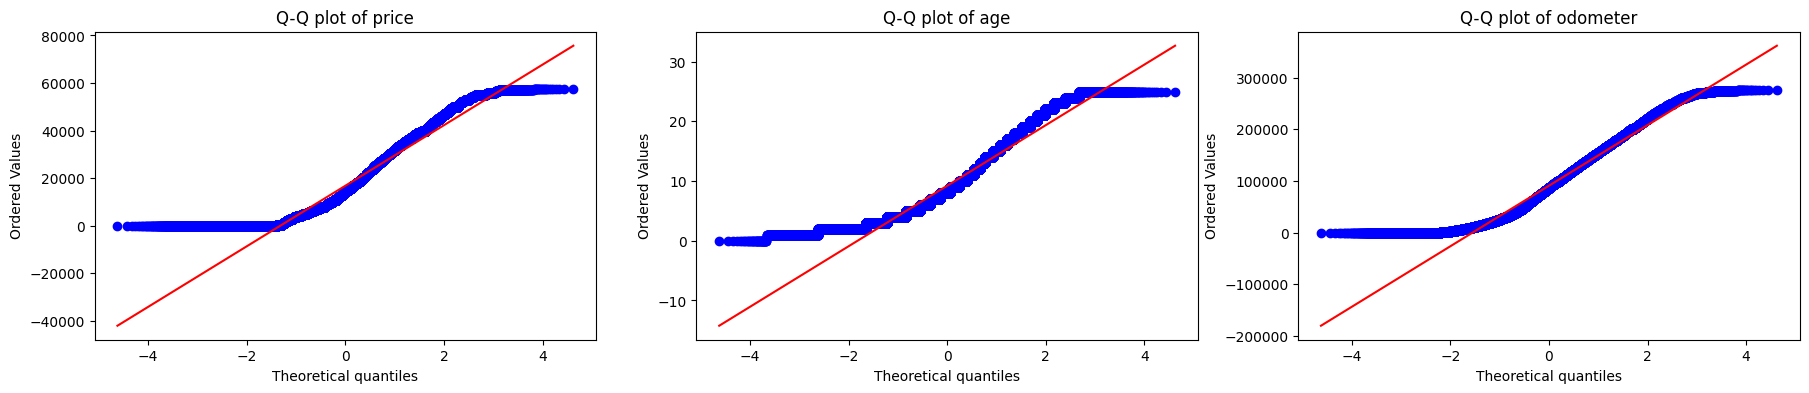

In [106]:
#Se generan gráficos de Q-Q para las 3 variables
plt.subplots_adjust(wspace = 4)
plt.subplots(1,3,figsize=(22,4))

plt.subplot(1, 3, 1)
stats.probplot(cars_df["price"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of price")

plt.subplot(1, 3, 2)
stats.probplot(cars_df["age"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of age")

plt.subplot(1, 3, 3)
stats.probplot(cars_df["odometer"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of odometer")

plt.show()

Las transformaciones *Box-Cox* y *Yeo-Johnson* son generalizaciones, pues incluyen casos especiales de transformaciones: logarítmica (`λ = 0`), recíproca (`λ = -1`),  raíz cuadrada (`λ = 0.5`) y más exponentes. En *Box-Cox* se evalúan varios valores de `λ` y se selecciona aquel que arroja la mejor transformación

La transformación de *Yeo-Johnson* es una extensión de la transformación de *Box-Cox* que ya no está restringida a valores positivos. En otras palabras, la transformación de *Yeo-Johnson* se puede utilizar en variables con valores cero y negativos, así como valores positivos. Cuando la variable solo tiene valores positivos, la transformación de *Yeo-Johnson* es como la transformación de *Box-Cox* de la variable más uno.

En este caso, como las variables `price` y `odometer` tienen valores de 0, utilizaremos *Yeo-Johnson*.

Recuerda que en `PowerTransformer()` el parámetro `standardize` por defecto es `True`. Con esto, después de hacer la transformación, el resultado se escala con *Z-score*, haciendo que la media sea 0 y la desviación estándar 1. Como en el ejercicio 6 ocuparás Min-Max para escalar, haz `standardize=False` para omitir el escalamiento en esta fase.

5b) Aplica la transformación Yeo-Johnson para reducir el sesgo en estas variables. Coloca el resultado en un dataframe denominado `transf_df` que contenga sólo las variables transformadas.

In [107]:
# Transformación de las variables numéricas sesgadas usando yeo-johnson
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method="yeo-johnson", standardize=False)
transf = transformer.fit_transform(cars_df[['price','age', 'odometer']])
transf_df = pd.DataFrame(transf, columns=transformer.get_feature_names_out())
transf_df

,price,age,odometer
0,194.933364,2.750246,623.675987
1,164.326657,3.338513,695.994731
2,209.204110,1.226721,346.526341
3,188.293578,2.149194,519.996769
4,137.708592,2.914458,949.705360
...,...,...,...
366323,167.423035,1.594338,456.840699
366324,187.243996,1.226721,270.474616
366325,198.386565,1.226721,153.705344
366326,182.964760,1.894201,440.666821


5c) Dibuja nuevamente los gráficos Q-Q y los histogramas para observar el efecto de la transformación.

<Figure size 640x480 with 0 Axes>

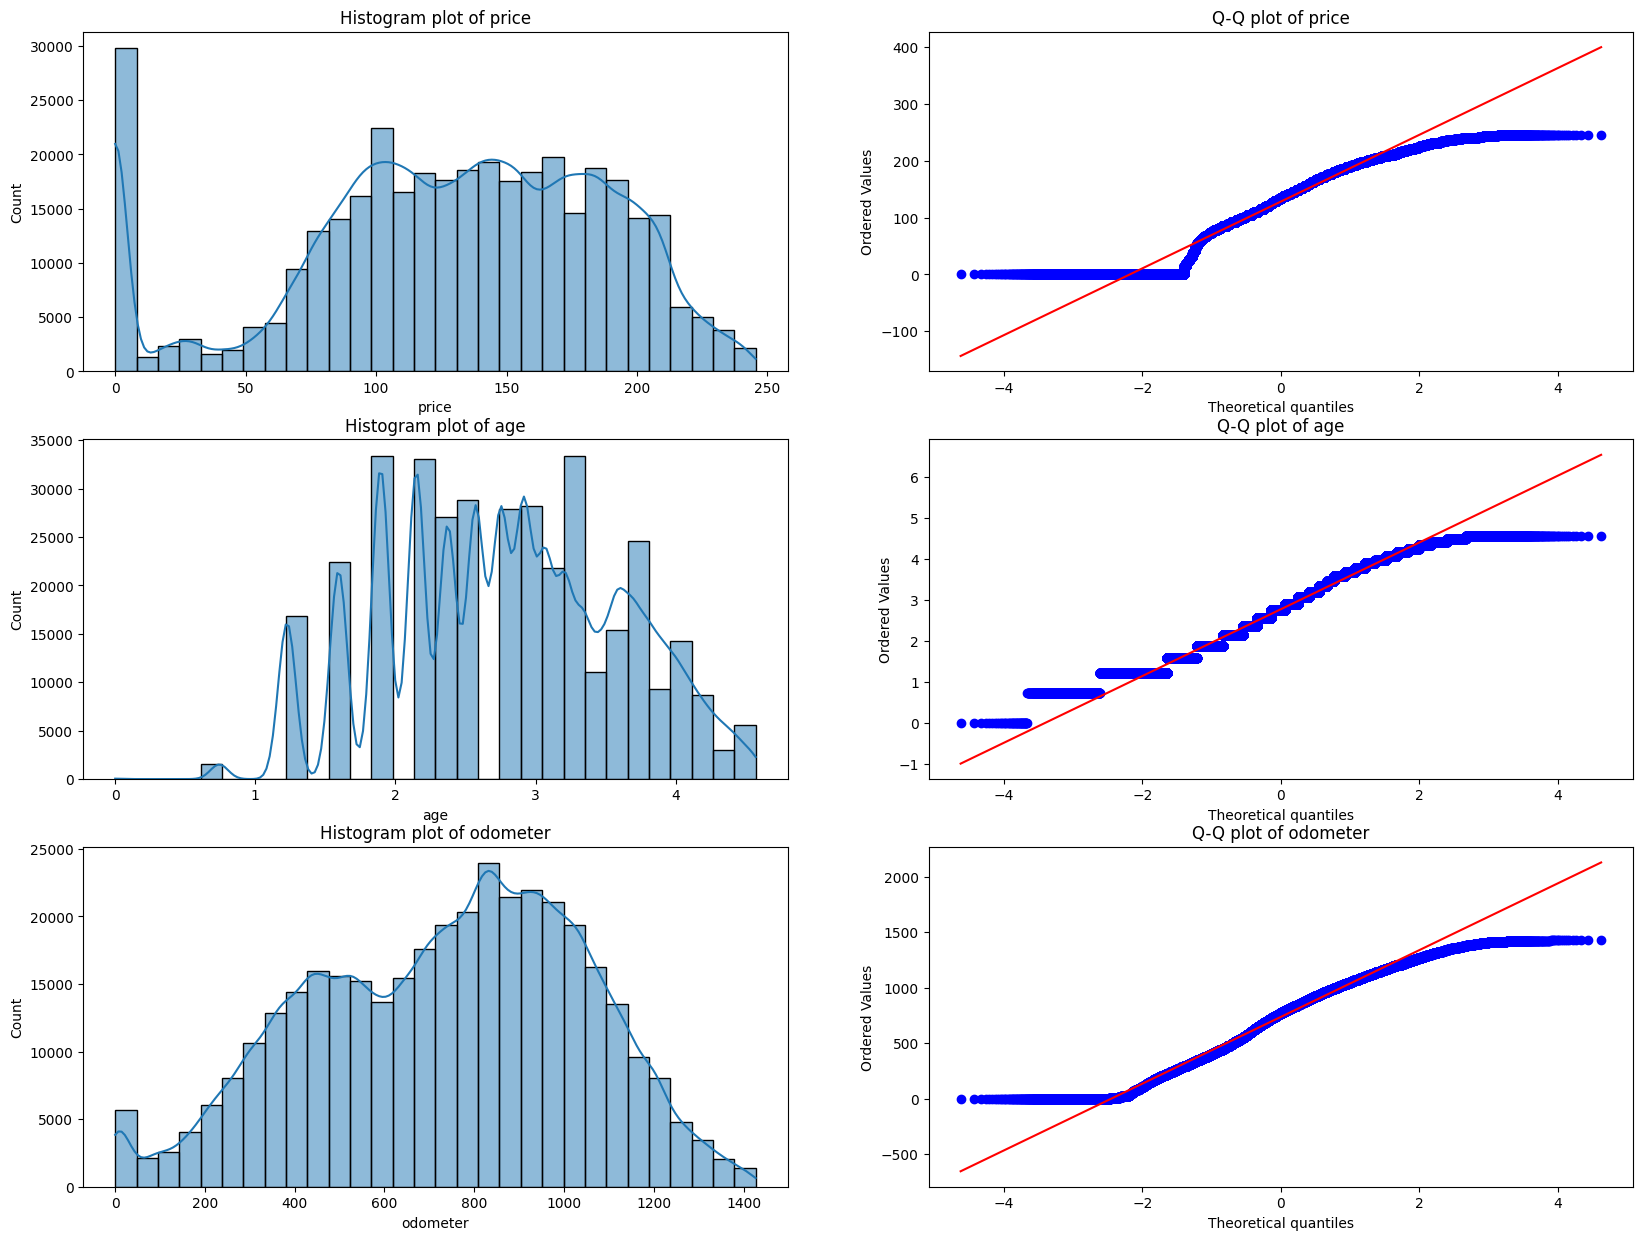

In [108]:
#Se generan gráficos de histograma y Q-Q para las 3 variables
plt.subplots_adjust(hspace = 1.5, wspace = 1.5)
plt.subplots(3,2,figsize=(20,15))

plt.subplot(3, 2, 1)
sns.histplot(transf_df["price"], kde=True, bins=30)
plt.title(f"Histogram plot of price")

plt.subplot(3, 2, 2)
stats.probplot(transf_df["price"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of price")

plt.subplot(3, 2, 3)
sns.histplot(transf_df["age"], kde=True, bins=30)
plt.title(f"Histogram plot of age")

plt.subplot(3, 2, 4)
stats.probplot(transf_df["age"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of age")

plt.subplot(3, 2, 5)
sns.histplot(transf_df["odometer"], kde=True, bins=30)
plt.title(f"Histogram plot of odometer")

plt.subplot(3, 2, 6)
stats.probplot(transf_df["odometer"], dist="norm", plot=plt)
plt.title(f"Q-Q plot of odometer")

plt.show()

## Escalando variables numéricas

6a) Como las tres variables poseen diferentes escalas, aplica el método Min-Max (al dataframe obtenido: `transf_df`) para que queden en el rango fijo [0 a 1]. Coloca el resultado en un dataframe denominado `minmax_df`.


In [109]:
# Escalamiento de las variables numéricas usando MinMax
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
minmax = scaler.fit_transform(transf_df)
minmax_df = pd.DataFrame(minmax, columns=scaler.get_feature_names_out())
minmax_df

,price,age,odometer
0,0.794060,0.601757,0.437060
1,0.669384,0.730471,0.487739
2,0.852192,0.268408,0.242839
3,0.767013,0.470246,0.364403
4,0.560956,0.637687,0.665534
...,...,...,...
366323,0.681997,0.348843,0.320145
366324,0.762738,0.268408,0.189543
366325,0.808127,0.268408,0.107714
366326,0.745306,0.414453,0.308810


6b) Dibuja nuevamente los histogramas para verificar que el escalamiento no cambia la distribución.

<Figure size 640x480 with 0 Axes>

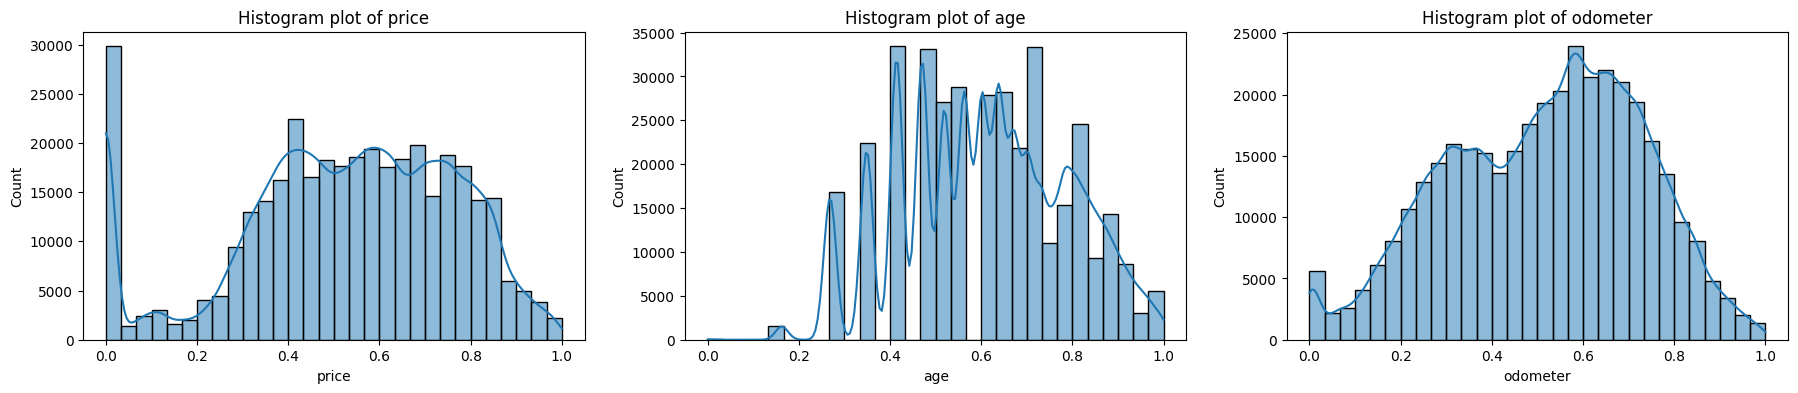

In [110]:
#Se generan gráficos de histograma
plt.subplots_adjust(wspace = 4)
plt.subplots(1,3,figsize=(22,4))

plt.subplot(1, 3, 1)
sns.histplot(minmax_df["price"], kde=True, bins=30)
plt.title(f"Histogram plot of price")

plt.subplot(1, 3, 2)
sns.histplot(minmax_df["age"], kde=True, bins=30)
plt.title(f"Histogram plot of age")

plt.subplot(1, 3, 3)
sns.histplot(minmax_df["odometer"], kde=True, bins=30)
plt.title(f"Histogram plot of odometer")

plt.show()

## Codificando variables categóricas


7a) Utiliza el método `describe()` para obtener el resumen de las estadísticas descriptivas en las variables categóricas.

In [111]:
#Se obtiene el resumen de las estadisticas descriptivas para la variables categóricas
cars_df.describe(include='object')

,region,region_url,manufacturer,model,fuel,title_status,transmission,type,state
count,366328,366328,366328,366328,366328,366328,366328,366328,366328
unique,404,413,40,19097,5,6,3,13,51
top,columbus,https://grandrapids.craigslist.org,ford,f-150,gas,clean,automatic,sedan,ca
freq,3188,2737,61660,7436,312085,354717,291628,154259,42062


7b) Según la cardinalidad observada, separa en dos listas (`highly_cardinal_variables` y `few_cardinal_variables`) los nombres de las variables con alta cardinalidad y baja cardinalidad respectivamente. Una variable es considerada de alta cardinalidad cuando tiene cientos de valores únicos.

In [112]:
# Obtener la cantidad de valores únicos en variables categóricas
cardinality = cars_df.select_dtypes(include=['object']).nunique()

# Separar en listas según la cardinalidad
highly_cardinal_variables = list(cardinality[cardinality >= 100].index)
few_cardinal_variables = list(cardinality[cardinality < 100].index)

print("Variables de alta cardinalidad:", highly_cardinal_variables)
print("Variables de baja cardinalidad:", few_cardinal_variables)

Variables de alta cardinalidad: ['region', 'region_url', 'model']
Variables de baja cardinalidad: ['manufacturer', 'fuel', 'title_status', 'transmission', 'type', 'state']


7c) Visualiza en gráficos de barras la frecuencias de las categorías para las variables con baja cardinalidad (en `few_cardinal_variables`)

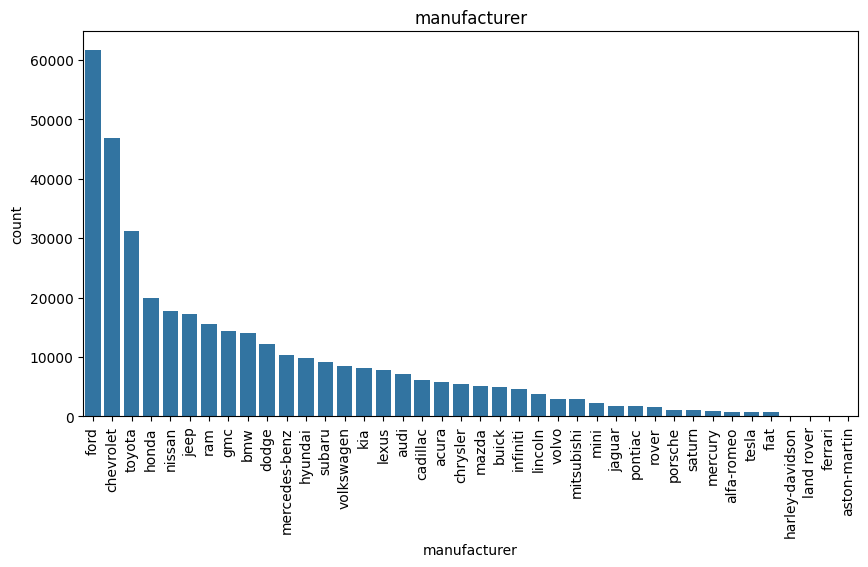

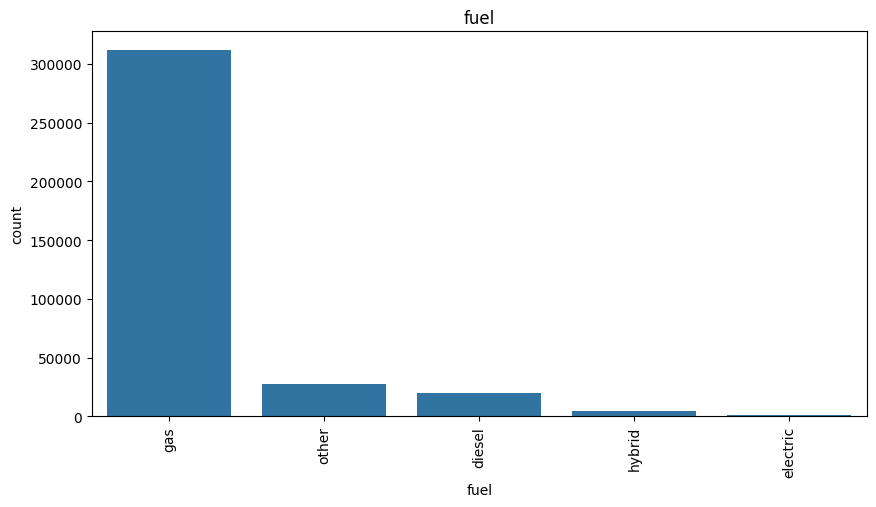

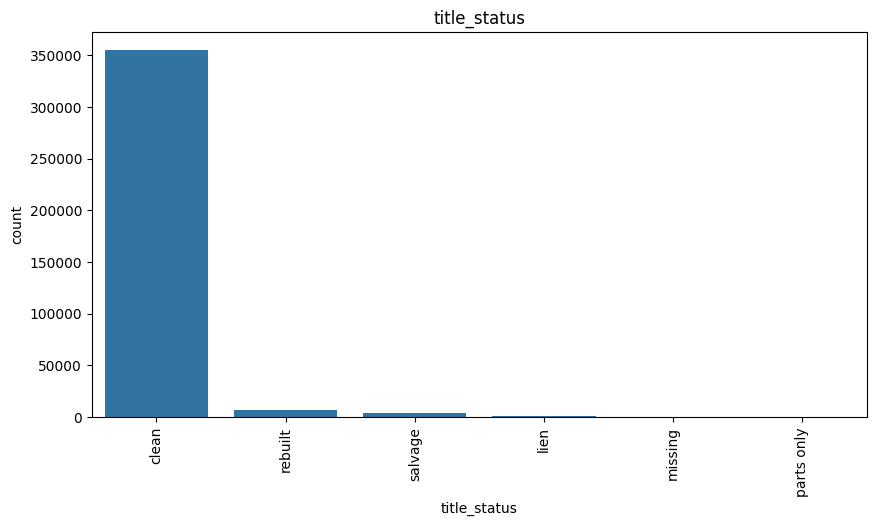

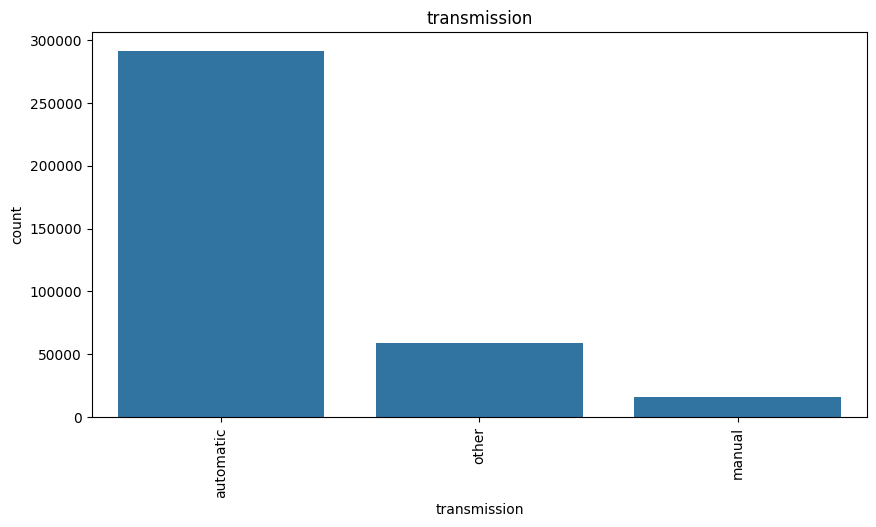

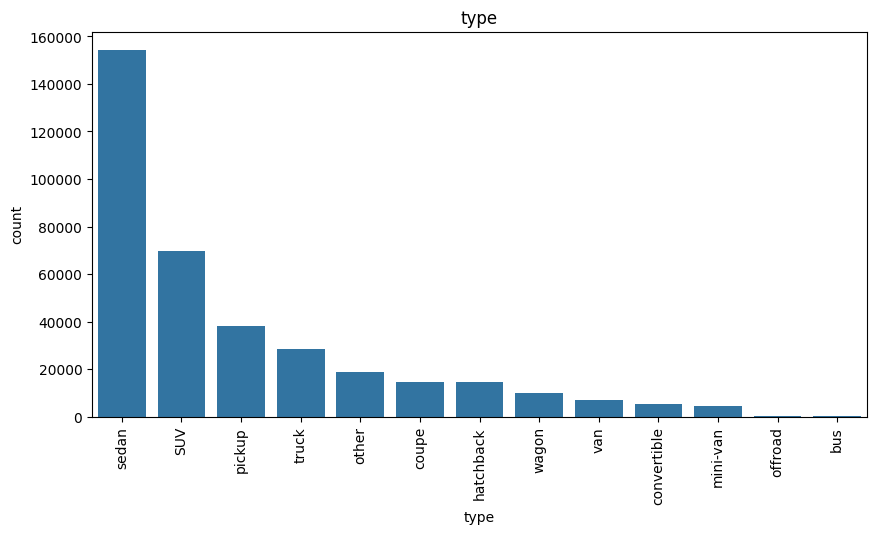

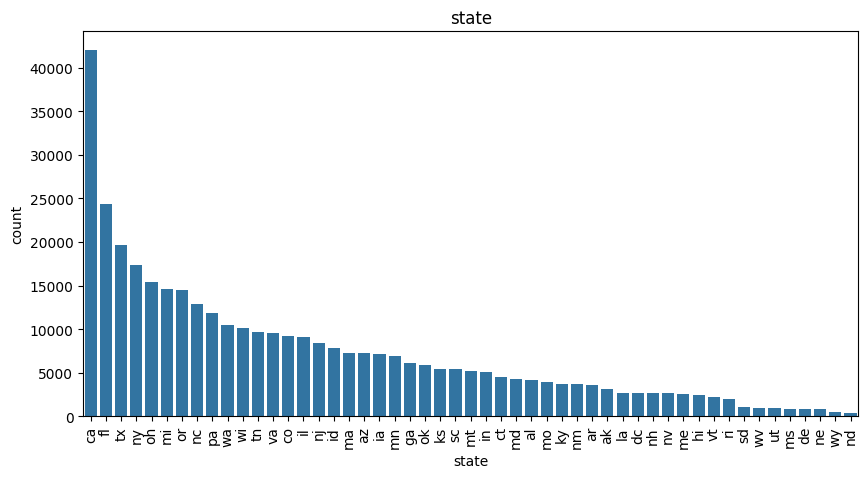

In [113]:
#Se realiza un gráfico de barras para las variables de baja cardinalidad
for column in few_cardinal_variables:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=cars_df, x=column, order = cars_df[column].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f"{column}")
    plt.show()

8. Aplica codificación *one-hot* a las variables en `few_cardinal_variables`, borrando la primera categoría (`drop='first'`). Coloca el resultado en un dataframe denominado `onehot_df`.

In [114]:
# Codificación de las variables categóricas de texto con one-hot
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(cars_df[few_cardinal_variables])
onehot_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
onehot_df

,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,manufacturer_dodge,manufacturer_ferrari,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
366324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
366325,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
366326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


9. Aplica codificación binaria a las variables en `highly_cardinal_variables`. Coloca el resultado en un dataframe denominado `binary_df`.

In [115]:
# Codificación de las variables categóricas de texto con codificación binaria
!pip install category_encoders
from category_encoders.binary import BinaryEncoder

encoder = BinaryEncoder()
binary_df = encoder.fit_transform(cars_df[highly_cardinal_variables])
binary_df

,region_0,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_url_0,...,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14
27,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
28,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
29,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1
30,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
31,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,1,1,0,0,1,0,1,0,0,1,...,1,1,0,0,1,0,0,1,1,0
426876,1,1,0,0,1,0,1,0,0,1,...,0,0,0,0,1,1,0,1,1,1
426877,1,1,0,0,1,0,1,0,0,1,...,0,0,0,0,0,1,1,0,1,1
426878,1,1,0,0,1,0,1,0,0,1,...,1,1,1,0,1,1,1,1,0,1


10. Concatena los dataframes obtenidos: `minmax_df` (cuyas variables numéricas ya están transformadas y escaladas) y las codificaciones anteriores (`onehot_df` y `binary_df`). Toma en cuenta que si los índices de los dataframes no coinciden, la concatenación no se realizará correctamente. Utiliza `reset_index(drop=True, inplace=True)` para restablecer los índices.

In [116]:
#Se concatenan los dataframes
minmax_df.reset_index(drop=True, inplace=True)
onehot_df.reset_index(drop=True, inplace=True)
binary_df.reset_index(drop=True, inplace=True)
df_final = pd.concat([minmax_df, onehot_df, binary_df], axis=1)
df_final

,price,age,odometer,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14
0,0.794060,0.601757,0.437060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,0.669384,0.730471,0.487739,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1,0
2,0.852192,0.268408,0.242839,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1,1
3,0.767013,0.470246,0.364403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
4,0.560956,0.637687,0.665534,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366323,0.681997,0.348843,0.320145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,0,1,1,0
366324,0.762738,0.268408,0.189543,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,1,0,1,1,1
366325,0.808127,0.268408,0.107714,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,1,1,0,1,1
366326,0.745306,0.414453,0.308810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,0,1,1,1,1,0,1
